# Observed vs. true fluorescence lifetime in homoFRET exhibiting systems

In [2]:
import os
import sys

path = os.path.abspath("")
splitted = path.split(os.sep)
user_independent = os.path.join(
    splitted[0] + os.sep, splitted[1], splitted[2], splitted[3]
)
src_path = os.path.join(user_independent, "GitHub", "Photoswitching")
sys.path.append(src_path)

import src.blinking as bl
import src.distributions as dist
import src.emissions as em
import src.fcs as fcs_p
import src.figure as fi
import src.fluorophores as fl
import src.formulas as fo
import src.miscellaneous as mi
import src.network as net
import src.simulation as si
import src.prediction as pr
import src.analysis as an
import src.transitions as tr

import numpy as np
import pandas as pd

%load_ext autoreload
%autoreload 2

import warnings


def custom_warning_format(msg, category, filename, lineno, line=None):
    if line is None:
        import linecache

        line = linecache.getline(filename, lineno)
    return f"WARNING for line: {line} {msg} \n"


warnings.formatwarning = custom_warning_format

Assumes an infinitesimally short laser pulse that assures only one fluorophore to be excited per pulse. Another pulse
starts only if all fluorophores are in their ground state.
This simulation is suited to demonstrate observed fluorescence lifetimes of homo-FRET experiments.
This simulation is NOT suited to demonstrate effects of energy transfers that are not homo-FRET, since they cannot
occur. Note: the observed fluorescence lifetime of systems without homo-FRET should equal the true fluorescence
lifetime.

TCSPC experiment uses a pulsed laser - different transition matrix depending on point in time. Doesn't work because of a few things, e.g., drawn times larger than next pulse have to be discarded, leading to false statistics

### Initial setup

In [3]:
fluorophores = fl.construct_fluorophores(name="cy5", distance=10, count=4)
fluorophore_system = fl.FluorophoreSystem(fluorophores=fluorophores)
excitation = tr.Transition(
    transition_type=tr.TransitionType.EXCITATION, rate=1e9, fluorophore_ids=[0, 1, 2, 3]
)
fluorescence = tr.Transition(
    transition_type=tr.TransitionType.FLUORESCENT_EMISSION,
    rate=1e9,
    fluorophore_ids=[0, 1, 2, 3],
)
hfret = tr.Transition(
    transition_type=tr.TransitionType.FRET,
    rate=1e10,
    fluorophore_ids=[(0, 1), (0, 2), (1, 0), (1, 3), (2, 0), (2, 3), (3, 1), (3, 2)],
)
hfret_2 = tr.Transition(
    transition_type=tr.TransitionType.FRET,
    rate=0.5e10,
    fluorophore_ids=[(0, 3), (1, 2), (2, 1), (3, 0)],
)
transitions = {
    "cy5": [excitation, fluorescence],
    "D: cy5, A: cy5, dist: 10.0": [hfret],
    "D: cy5, A: cy5, dist: 14.142": [hfret_2],
}

transition_set = tr.TransitionSet(transitions, fluorophore_system)
transition_set.finalize()

### Modify transition matrix

In [4]:
def modify_transition_matrix(transition_set):
    """
    Modifies the transition matrix in a way that prevents multiple fluorophores to be
    in a different photophysical state than the ground state simultaneously. This is
    achieved by setting all excitation rates that do not effect an all ground state
    fluorophore configuration to zero.
    """
    df = transition_set.combined_state_transitions_df
    excitations = df[df["abbreviation"] == "EXC"]
    indices_to_modify = excitations.index.values[
        transition_set.fluorophore_system.count :
    ]
    transition_rate_matrix = transition_set.transition_matrix * np.expand_dims(
        transition_set.row_sums, axis=1
    )
    transition_rate_matrix[:, indices_to_modify] = 0
    modified_row_sums = transition_rate_matrix.sum(axis=1)
    modified_transition_matrix = np.divide(
        transition_rate_matrix,
        np.expand_dims(modified_row_sums, axis=1),
        out=np.zeros_like(transition_rate_matrix),
        where=modified_row_sums != 0,
    )
    return modified_transition_matrix, modified_row_sums


mod_transition_matrix, mod_row_sums = modify_transition_matrix(transition_set)

### Run simulation

In [5]:
start_at = tuple(np.zeros(shape=transition_set.fluorophore_system.count, dtype=int))
df = transition_set.combined_state_transitions_df
start_index = df[df["final_state"] == start_at].index[0]

time_series, transition_series = si.direct_method_steps(
    transition_matrix=mod_transition_matrix,
    row_sums=mod_row_sums,
    start_index=start_index,
    size=int(1e5),
    seed=1,
)

### Get true and observed fluorescence lifetime

In [6]:
def get_lifetimes(transition_series, time_series, transition_set):
    """
    True fluorescence lifetime: time between any excitation and fluorescent emission 
    from the same fluorophore.
    Observed lifetimes: times between photon-driven excitation and fluorescent emission 
    not considering whether the emission comes from the originally excited fluorophore.
    """
    df = transition_set.combined_state_transitions_df
    excitation_values = df[df["abbreviation"] == "EXC"].index.values
    fluorescence_values = df[df["abbreviation"] == "FLU"].index.values
    excitation_indices = np.in1d(transition_series, excitation_values).nonzero()[0]
    emission_indices = np.in1d(transition_series, fluorescence_values).nonzero()[0]
    excitation_times = time_series[excitation_indices + 1]
    emission_times = time_series[emission_indices + 1]
    pre_emission_times = time_series[emission_indices]
    true_fluorescence_lifetime = np.mean(emission_times - pre_emission_times)
    corresponding_excitation_time_indices = (
        np.searchsorted(excitation_times, emission_times, side="right") - 1
    )
    corresponding_excitation_times = excitation_times[
        corresponding_excitation_time_indices
    ]

    observed_lifetimes = emission_times - corresponding_excitation_times

    return true_fluorescence_lifetime, observed_lifetimes


true_tau, obs_tau = get_lifetimes(
    transition_series=transition_series,
    time_series=time_series,
    transition_set=transition_set,
)

### Computationally predict observed and true fluorescence lifetime

In [7]:
def get_transition_probabilities(transition_df, fluorophore_system):
    """
    Gets the probabilities of homoFRET and fluorescent deexcitation and the true 
    fluorescence lifetime. Note: the values returned reflect a setup where only one 
    fluorophore is excited at a time. This means that if a fluorophore is in S1, all 
    other fluorophores are, at all times, in S0. Hence, if the rate of homoFRET is 
    non-zero, it has to be considered constantly and alters the true fluorescence 
    lifetime and probability of fluorescence. Additionally, if more than 2 fluorophores 
    are present, a total FRET rate is calculated depending on the distances.
    """
    distances, occurrences = np.unique(
        list(fluorophore_system.distances.values()), return_counts=True
    )
    occurrences = occurrences / fluorophore_system.count
    df = transition_df
    fluorescence_rate = df[df["abbreviation"] == "FLU"]["rate"].values[0]
    non_et_s1_rates = df[df["initial_state"] == tr.SingleState.S1]["rate"]
    et_s1_s0_transitions = df[df["initial_state"] == tr.PairedState.S1_S0]
    et_s1_s0_rate_sum = 0
    for i, ((fluorophore, identity), transition) in enumerate(
        et_s1_s0_transitions.iterrows()
    ):
        et_s1_s0_rate_sum += transition["rate"] * occurrences[i]
    fluorescence_lifetime = 1 / (non_et_s1_rates.sum() + et_s1_s0_rate_sum)
    hfret_probability = et_s1_s0_rate_sum * fluorescence_lifetime
    fluorescence_probability = fluorescence_rate * fluorescence_lifetime

    return fluorescence_lifetime, hfret_probability, fluorescence_probability


def predict(transition_set, accuracy=10, size=10, seed=None):
    """
    Compute times between photon-driven excitation and fluorescent emission not 
    considering whether the emission comes from the originally excited fluorophore.
    accuracy : int : The accuracy of the prediction. Higher energy transfer rates need 
    higher accuracy to accomplish the same quality of prediction.
    """
    from scipy.stats import erlang

    pred_tau, hfret_probability, fluorescence_probability = (
        get_transition_probabilities(
            transition_set.transition_df, transition_set.fluorophore_system
        )
    )
    rng = np.random.default_rng(seed)
    probabilities = []
    distributions = []
    for i in range(accuracy):
        probability = fluorescence_probability * hfret_probability**i  # x**0 = 1
        probabilities.append(probability)
        distribution = erlang(a=i + 1, scale=pred_tau)
        distributions.append(distribution)
    weights = probabilities / np.sum(
        probabilities
    )  # otherwise, probabilites do not add up to 1
    random_numbers = np.random.uniform(0, 1, size)
    cumulative_probabilities = np.cumsum(weights)
    predicted_obs_lifetimes = np.ones(size)

    for i in range(size):
        index = np.searchsorted(cumulative_probabilities, random_numbers[i])
        predicted_obs_lifetimes[i] = distributions[index].rvs(size=1, random_state=rng)[
            0
        ]

    return pred_tau, predicted_obs_lifetimes


pred_true_tau, pred_obs_tau = predict(
    transition_set=transition_set, accuracy=int(1e5), size=100, seed=1
)

### Plot the results

Text(0.3, 0.5, '$\\mu_{pred/true}$ = 3.85e-11')

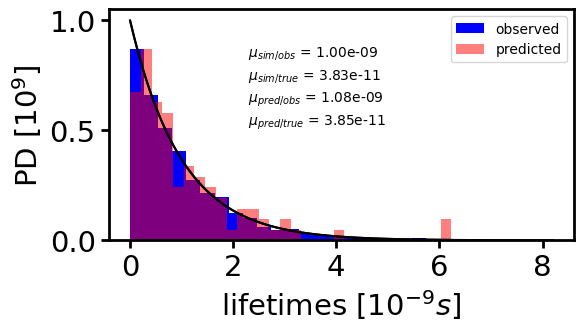

In [13]:
from scipy.stats import expon

distr = expon(scale=1e-9)
ax = fi.universal_figure(
    type_="hist", data=obs_tau, density=True, plot_distribution=distr, bins=30,
    label='observed',
)
fi.universal_figure(
    type_="hist",
    data=pred_obs_tau,
    density=True,
    plot_distribution=distr,
    bins=30,
    axes=ax[0, 0],
    color="red",
    alpha=0.5,
    xlabel=r'lifetimes $[10^{-9}s]$',
    ylabel=r'PD $[10^{9}]$',
    label='predicted',
    tick_style_y='sci',
    tick_style_x='sci',
    legend=True
)
ax[0, 0].text(
    x=0.3,
    y=0.8,
    s=rf"$\mu_{{sim/obs}}$ = {np.mean(obs_tau):.2e}",
    transform=ax[0, 0].transAxes,
)
ax[0, 0].text(
    x=0.3,
    y=0.7,
    s=rf"$\mu_{{sim/true}}$ = {true_tau:.2e}",
    transform=ax[0, 0].transAxes,
)
ax[0, 0].text(
    x=0.3,
    y=0.6,
    s=rf"$\mu_{{pred/obs}}$ = {np.mean(pred_obs_tau):.2e}",
    transform=ax[0, 0].transAxes,
)
ax[0, 0].text(
    x=0.3,
    y=0.5,
    s=rf"$\mu_{{pred/true}}$ = {pred_true_tau:.2e}",
    transform=ax[0, 0].transAxes,
)

### As a function of energy transfer rate (i.e., distance)

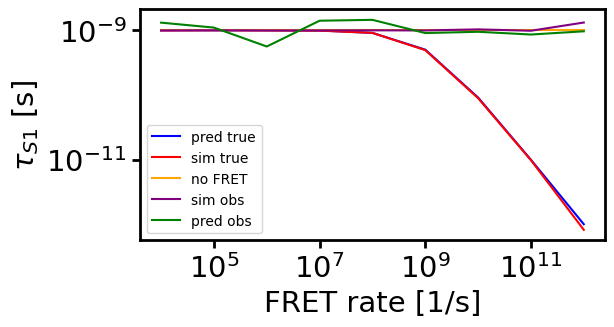

In [16]:
energy_transfer_rates = np.logspace(4, 12, num=9)
fluorophores = fl.construct_fluorophores("cy5", 10, 2)
fluorophore_system = fl.FluorophoreSystem(fluorophores=fluorophores)
excitation = tr.Transition(
    transition_type=tr.TransitionType.EXCITATION, rate=1e9, fluorophore_ids=[0, 1]
)
fluorescence = tr.Transition(
    transition_type=tr.TransitionType.FLUORESCENT_EMISSION,
    rate=3e8,
    fluorophore_ids=[0, 1],
)
ic = tr.Transition(
    transition_type=tr.TransitionType.INTERNAL_CONVERSION_S,
    rate=7e8,
    fluorophore_ids=[0, 1],
)

pred_true_lifetimes = []
pred_obs_lifetimes = []
unchanged_lifetimes = []
sim_obs_lifetimes = []
sim_true_lifetimes = []
for energy_transfer_rate in energy_transfer_rates:
    hfret = tr.Transition(
        transition_type=tr.TransitionType.FRET,
        rate=energy_transfer_rate,
        fluorophore_ids=[(0, 1), (1, 0)],
    )
    transitions = {
        "cy5": [excitation, fluorescence, ic],
        "D: cy5, A: cy5, dist: 10.0": [hfret],
    }
    transition_set = tr.TransitionSet(transitions, fluorophore_system)
    transition_set.finalize()
    mod_transition_matrix, mod_row_sums = modify_transition_matrix(transition_set)
    start_at = tuple(np.zeros(shape=transition_set.fluorophore_system.count, dtype=int))
    df = transition_set.combined_state_transitions_df
    start_index = df[df["final_state"] == start_at].index[0]

    time_series, transition_series = si.direct_method_steps(
        transition_matrix=mod_transition_matrix,
        row_sums=mod_row_sums,
        start_index=start_index,
        size=int(1e5),
        seed=1,
    )
    true_tau, obs_tau = get_lifetimes(
        transition_series=transition_series,
        time_series=time_series,
        transition_set=transition_set,
    )
    pred_tau, predicted_obs_lifetimes = predict(
        accuracy=100000, transition_set=transition_set
    )

    pred_obs_lifetimes.append(np.mean(predicted_obs_lifetimes))
    pred_true_lifetimes.append(pred_tau)
    sim_obs_lifetimes.append(np.mean(obs_tau))
    sim_true_lifetimes.append(true_tau)
    unchanged_lifetimes.append(1e-9)

axes = fi.universal_figure(
    type_="line",
    data=[energy_transfer_rates, pred_true_lifetimes],
    yscale="log",
    xscale="log",
    label="pred true",
)
axes = fi.universal_figure(
    type_="line",
    data=[energy_transfer_rates, sim_true_lifetimes],
    axes=axes,
    color="red",
    label="sim true",
)
axes = fi.universal_figure(
    type_="line",
    data=[energy_transfer_rates, unchanged_lifetimes],
    axes=axes,
    color="orange",
    label="no FRET",
)
axes = fi.universal_figure(
    type_="line",
    data=[energy_transfer_rates, sim_obs_lifetimes],
    axes=axes,
    color="purple",
    label="sim obs",
)
axes = fi.universal_figure(
    type_="line",
    data=[energy_transfer_rates, pred_obs_lifetimes],
    axes=axes,
    color="green",
    label="pred obs",
    legend=True,
    xlabel="FRET rate [1/s]",
    ylabel=r'$\tau_{S1}$ [s]',
)